In [1]:
import pandas as pd
import numpy as np
import json
import os
from jiwer import wer, cer
from datasets import load_dataset
import re
from num2words import num2words
from scipy.stats import iqr, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\ATHO0358\Documents\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_transcription(sentence: str):
    """
    Function to preprocess the ground truth and predicted transcripts before computing the performance using WER, CER etc...
    Should standardize the text to lowercase, no punctuations or special characters.
    It should also map all occurrences of numbers to textual representations using library function.
    """
    sentence = str.lower(sentence)
    sentence = re.sub(r'-(?!\d)', '', sentence)             # Remove - that are not followed by a number
    sentence = re.sub(r'(?<!\d)\.|\.?(?!\d)', '', sentence) # Remove . that are not enclosed by two numbers
    sentence = re.sub(r'[^\w\s.-]', '', sentence)           # Remove all punctuation except for the - and .
    sentence = re.sub(' +', ' ', sentence)                  # Replacing all duplicate spaces with single space.
    
    sentence_copy = str(sentence)

    for s in sentence.split():
        try: 
            num = float(s)
            word_rep = str(num2words(number=num))
            sentence_copy = sentence_copy.replace(s, word_rep)
        except ValueError as e:
            continue

    return sentence_copy    

In [ ]:
ds = load_dataset("CoRal-project/coral-v3", "conversation", split="test")
ds = ds.to_pandas()

In [ ]:
int8_df = pd.read_json('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/exp_1/int8/asr_output_coral_segments.jsonl', lines=True)
fp32_df = pd.read_json('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/exp_1/fp32/asr_output_coral_segments.jsonl', lines=True)

In [56]:
def calculate_results(df, err_type: str):
    ref_lookup = ds.set_index("id_conversation")["text"].to_dict()
    epochs = sorted(df["epoch"].unique())

    results = {epoch: [] for epoch in epochs}

    for _, row in df.iterrows():

        # concatenate references in the order given
        reference = " ".join(ref_lookup[s] for s_list in row["segment_ids"] for s in s_list)
        hypothesis = " ".join(row["hypothesis"])
        if err_type == 'wer':
            error = wer(clean_transcription(reference), clean_transcription(hypothesis))
        elif err_type == 'cer':
            error = cer(clean_transcription(reference), clean_transcription(hypothesis))
        results[row["epoch"]].append(error)

    res_df = pd.DataFrame(dict((k, pd.Series(v)) for k, v in results.items()))
    return res_df.to_numpy()

In [57]:
data_int8_cer = calculate_results(int8_df, 'cer')
data_int8_wer = calculate_results(int8_df, 'wer')

data_fp32_cer = calculate_results(fp32_df, 'cer')
data_fp32_wer = calculate_results(fp32_df, 'wer')


In [72]:
print(f'INT8 CER: {np.average(data_int8_cer):.2%}')
print(f'INT8 WER: {np.average(data_int8_wer):.2%}')
print(f'FP32 CER: {np.average(data_fp32_cer):.2%}')
print(f'FP32 WER: {np.average(data_fp32_wer):.2%}')

INT8 CER: 14.83%
INT8 WER: 24.55%
FP32 CER: 14.47%
FP32 WER: 24.06%


In [65]:
# Plot the distribution of the error rate... The difference between FP32 and INT8 for CER and WER respectively.
def plot(data_fp32,data_int8, err_type):
    epoch_avg_fp32 = np.average(data_fp32, axis=1)
    epoch_avg_int8 = np.average(data_int8, axis=1)

    diff = epoch_avg_int8 - epoch_avg_fp32
    
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    cohen = mean_diff / std_diff
    print(f'Mean of difference: {mean_diff}, Standard Deviation: {std_diff} and Cohens d: {cohen}')

    iqr_diff = iqr(diff)
    bin_width = 2 * iqr_diff * ((len(diff))**(-1/3))

    sns.histplot(diff, kde=True, bins=20, binwidth=bin_width, color='purple')
    # Labels and title
    plt.xlabel(err_type)
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

Mean of difference: 0.003554059427425029, Standard Deviation: 0.018953553207893103 and Cohens d: 0.18751415043090497


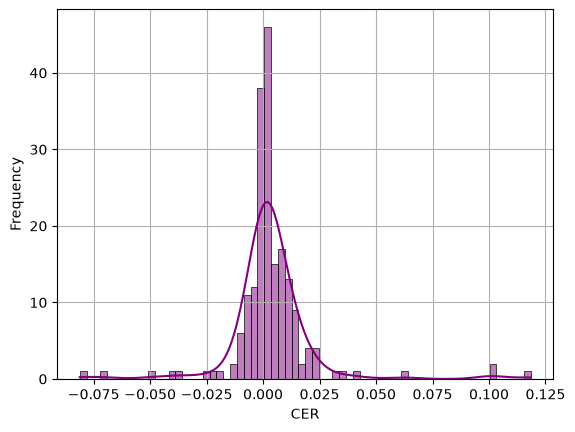

In [66]:
plot(data_int8=data_int8_cer, data_fp32=data_fp32_cer, err_type='CER')

Mean of difference: 0.004900500371151275, Standard Deviation: 0.02273111125281601 and Cohens d: 0.21558560497319215


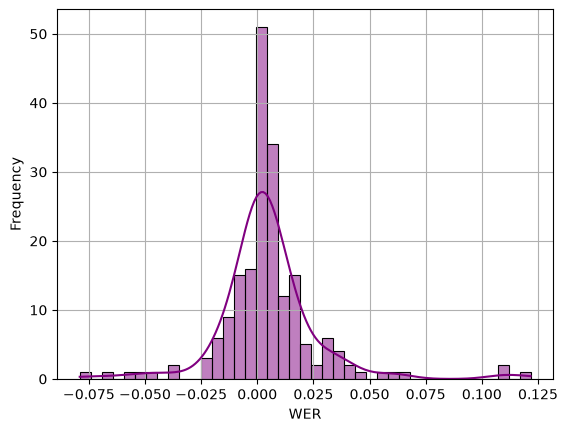

In [67]:
plot(data_int8=data_int8_wer, data_fp32=data_fp32_wer, err_type='WER')

Given that both distributions show a bell curve strongly indicates a normal distribution of the udnerlying data samples. Therefore, I will test the results with a paired t-test.

In [69]:
def paired_ttest(data_fp32, data_int8):
    epoch_mean_fp32 = np.mean(data_fp32, axis=1)
    epoch_mean_int8 = np.mean(data_int8, axis=1)

    res = ttest_rel(epoch_mean_int8,
                    epoch_mean_fp32,
                    alternative="greater")
    print(res.statistic)
    print(res.pvalue)

In [70]:
paired_ttest(data_fp32=data_fp32_cer, data_int8=data_int8_cer)
paired_ttest(data_fp32=data_fp32_wer, data_int8=data_int8_wer)

2.611769894667957
0.0048579158433598515
3.002760013038256
0.0015147842952830646


Analysis of the Wrist Angel Dataset being run through the ASR module only.

In [27]:
wa_results = pd.read_json('L:\\Auditdata\\Wrist Angel - Video\\Amalie Sommer\\repo\\thesis_multi_speaker_asr\\data\\results\\cpu_threads_10\\run_4\\asr_output_WA_int8.jsonl', lines=True)
wa_truth = pd.read_json('L:\\Auditdata\\Wrist Angel - Video\\Amalie Sommer\\repo\\thesis_multi_speaker_asr\\data\\audio\\clipped\\transcripts.jsonl', lines=True)

In [29]:
wa_results.head(20)

,epoch,batch_id,segments,wall_time,cpu_time
0,0,0,"[{'audio_id': 'id4_baseline_exposure1', 'clip_...",297.486493,2537.531250
1,0,1,"[{'audio_id': 'id4_baseline_exposure2', 'clip_...",253.202795,2359.734375
2,0,2,"[{'audio_id': 'id4_week8_exposure1', 'clip_off...",226.629617,2148.171875
3,0,3,"[{'audio_id': 'id4_week8_exposure2', 'clip_off...",252.881209,2412.296875
4,0,4,"[{'audio_id': 'id6_baseline_exposure2', 'clip_...",229.760111,2184.015625
5,0,5,"[{'audio_id': 'id6_baseline_exposure3', 'clip_...",254.222704,2429.296875
6,0,6,"[{'audio_id': 'id6_week8_exposure1', 'clip_off...",272.755452,2595.187500
7,0,7,"[{'audio_id': 'id18_baseline_suds', 'clip_offs...",322.061811,3073.046875
8,0,8,"[{'audio_id': 'id38_baseline_exposure', 'clip_...",241.952214,2289.609375
9,0,9,"[{'audio_id': 'id38_baseline_exposure', 'clip_...",240.441322,2278.421875


In [30]:
wa_results = wa_results.groupby('epoch', as_index=False).agg({
    'segments': 'sum'
})

In [31]:
wa_results.head(10)

,epoch,segments
0,0,"[{'audio_id': 'id4_baseline_exposure1', 'clip_..."
1,1,"[{'audio_id': 'id4_baseline_exposure1', 'clip_..."
2,2,"[{'audio_id': 'id4_baseline_exposure1', 'clip_..."
3,3,"[{'audio_id': 'id4_baseline_exposure1', 'clip_..."
4,4,"[{'audio_id': 'id4_baseline_exposure1', 'clip_..."


In [40]:
import itertools
for i, row in wa_results.iterrows():
    print(row['segments'])
    for key, seg in itertools.groupby(row['segments'][0], lambda x: x['audio_id']):
        seg_list = list(seg)
        print(seg_list)

[{'audio_id': 'id4_baseline_exposure1', 'clip_offset': 279.0, 'words': [{'start': 1.54, 'end': 1.94, 'word': 'Ja'}, {'start': 1.94, 'end': 2.34, 'word': ' jamen'}, {'start': 2.34, 'end': 2.54, 'word': ' ellers'}, {'start': 2.54, 'end': 2.64, 'word': ' jeg'}, {'start': 2.64, 'end': 3.08, 'word': ' registrerer'}, {'start': 3.08, 'end': 3.16, 'word': ' det'}, {'start': 3.16, 'end': 3.3, 'word': ' bare'}, {'start': 3.3, 'end': 3.4, 'word': ' ikke'}, {'start': 3.4, 'end': 3.7, 'word': ' så'}, {'start': 3.7, 'end': 3.98, 'word': ' ja'}, {'start': 4.58, 'end': 6.8, 'word': ' så'}, {'start': 7.6, 'end': 7.88, 'word': ' gør'}, {'start': 7.88, 'end': 7.92, 'word': ' man'}, {'start': 7.92, 'end': 8.06, 'word': ' det'}, {'start': 8.06, 'end': 8.34, 'word': ' derhjemme'}, {'start': 8.34, 'end': 8.44, 'word': ' at'}, {'start': 8.44, 'end': 8.54, 'word': ' man'}, {'start': 8.54, 'end': 8.74, 'word': ' også'}, {'start': 8.74, 'end': 9.32, 'word': ' registrerer'}, {'start': 9.32, 'end': 9.36, 'word': '

TypeError: string indices must be integers, not 'str'

In [ ]:
print(len(wa_results))
wa_results.groupby('')
wa_results = wa_results['segments'].map(lambda z: z)
hypothesis = {}
for list in wa_results:
    for i, item in enumerate(list):
        id = item['audio_id']
        if id in hypothesis.keys():
            hypothesis[id].append(item['words'])
        else:
            hypothesis[id] = [item['words']]



125


In [26]:
hyp = {}
for k, v in hypothesis.items():
    print(f'Key: {k}, Values: {len(v)}')
    text = " ".join([w['word'] for words in v for w in words])
    hyp[k] = text
    print(f'Key: {k}.... Text: {text}')

Key: id4_baseline_exposure1, Values: 30
Key: id4_baseline_exposure1.... Text: Ja  jamen  ellers  jeg  registrerer  det  bare  ikke  så  ja  så  gør  man  det  derhjemme  at  man  også  registrerer  det  der  så  nu  begynder  vi  egentlig  bare  ja  eller  10  33  tror  jeg  det  hedder  ja  så  hvis  vi  nu  snakker  om  det  her  med  at  røre  ved  den  så  prøver  vi  at  at  så  spørger  jeg  derefter  med  tid  hvor  ubehageligt  det  er  så  hvis  du  forestiller  dig  at  du  lagde  hånden  på  den  og  du  så  kigger  på  hånden  bagefter  hvordan  vil  det  føles Helt  vildt.  Gammeldags.  Ikke.  Altså  jeg  ved  ikke  jeg  kan  med  min  egen  mobil  og  og  de  fleste  andre  nu  får  jeg  følt  lige  præcis  den  der  besked Så  hvis  vi  nu  bare  lige  prøver  nu  har  den  nu  har  den  18  dage  på  50  60  og  så  ser  vi  hvad  der  sker  sammen  med  det  der  ubehag  nej  nu  skal  vi  ikke  prøve  det  nu  sidder  vi  bare  lige  og  snakker  lidt  og  så  kan  du

In [8]:
print(len(wa_truth))
wa_truth.head()

24


,audio_id,filepath,duration,offset,segments
0,id18_baseline_suds,data\\audio\\id18_baseline_suds.flac,635.0,425,"[{'start': 428, 'end': 467, 'speaker_id': 'I',..."
1,id38_baseline_exposure,data\\audio\\id38_baseline_exposure.flac,763.0,550,"[{'start': 550, 'end': 557, 'speaker_id': 'B',..."
2,id38_week8_exposure,data\\audio\\id38_week8_exposure.flac,123.0,386,"[{'start': 386, 'end': 394, 'speaker_id': 'V',..."
3,id47_baseline_exposure2,data\\audio\\id47_baseline_exposure2.flac,797.5,263,"[{'start': 263, 'end': 267, 'speaker_id': 'B',..."
4,id47_baseline_exposure3,data\\audio\\id47_baseline_exposure3.flac,124.0,0,"[{'start': 1, 'end': 9, 'speaker_id': 'B', 'te..."


In [ ]:
for i, row in wa_truth.iterrows():
    audio_id = row['audio_id']
    pred = hyp[audio_id]
    ref = row['segments']
    ref = " ".join([r['text'] for r in ref])

    pred = clean_transcription(pred)
    ref = clean_transcription(ref)

    wer = 

In [10]:
def get_walltime(filename: str):
    epoch_pattern = r'Epoch: \d+'
    walltime_pattern = r'Walltime: [+-]?([0-9]*[.])?[0-9]+'

    result = []
    current_epoch = None
    epoch_result = []
    with open(filename, 'r') as file:
        for line in file:
            m_epoch = re.search(epoch_pattern, line)
            m_walltime = re.search(walltime_pattern, line)
            if not m_epoch:
                continue
            elif not m_walltime:
                continue

            epoch = str.split(m_epoch.group(), sep=' ')[-1]
            walltime = str.split(m_walltime.group(), sep=' ')[-1]

            if current_epoch is None:
                current_epoch = epoch
                epoch_result.append(float(walltime))
            elif current_epoch != epoch:
                # end of epoch values so save and reset to next epoch...
                result.append(epoch_result)
                epoch_result = [float(walltime)]
                current_epoch = epoch
            else:
                epoch_result.append(float(walltime))
        result.append(epoch_result)

    return np.array(result)

In [12]:
wa_walltime = get_walltime(filename='L:\\Auditdata\\Wrist Angel - Video\\Amalie Sommer\\repo\\thesis_multi_speaker_asr\\data\\results\\cpu_threads_10\\run_4\\pipeline_performance.log')
print(wa_walltime.shape)
wa_walltime = np.transpose(wa_walltime)
print(wa_walltime.shape)


(5, 25)
(25, 5)


Mean of difference: 224.44509956800002, Standard Deviation: 22.477489263287612 and Cohens d: 9.985327851299889


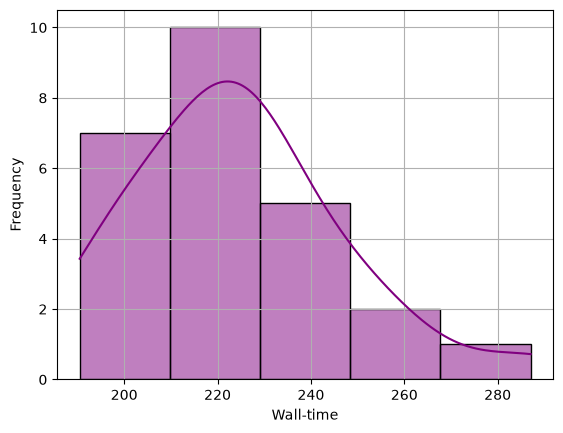

In [14]:
wa_walltime_avg_int8 = np.average(wa_walltime, axis=1)

mean_diff = np.mean(wa_walltime_avg_int8)
std_diff = np.std(wa_walltime_avg_int8, ddof=1)

cohen = mean_diff / std_diff
print(f'Mean of difference: {mean_diff}, Standard Deviation: {std_diff} and Cohens d: {cohen}')

iqr_diff = iqr(wa_walltime_avg_int8)
bin_width = 2 * iqr_diff * ((len(wa_walltime_avg_int8))**(-1/3))

sns.histplot(wa_walltime_avg_int8, kde=True, bins=10, binwidth=bin_width, color='purple')
# Labels and title
plt.xlabel('Wall-time')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [ ]:
def calculate_results(df, err_type: str):
    ref_lookup = ds.set_index("id_conversation")["text"].to_dict()
    epochs = sorted(df["epoch"].unique())

    results = {epoch: [] for epoch in epochs}

    for _, row in df.iterrows():

        # concatenate references in the order given
        reference = " ".join(ref_lookup[s] for s_list in row["segment_ids"] for s in s_list)
        hypothesis = " ".join(row["hypothesis"])
        if err_type == 'wer':
            error = wer(clean_transcription(reference), clean_transcription(hypothesis))
        elif err_type == 'cer':
            error = cer(clean_transcription(reference), clean_transcription(hypothesis))
        results[row["epoch"]].append(error)

    res_df = pd.DataFrame(dict((k, pd.Series(v)) for k, v in results.items()))
    return res_df.to_numpy()

In [2]:
import pandas as pd

df = pd.read_csv('L:\\Auditdata\\Wrist Angel - Video\\Amalie Sommer\\repo\\thesis_multi_speaker_asr\\data\\audio\\segments\\metadata_new.csv')
sorted_durations = df.sort_values(by=['segment_duration'], ascending=False)
print(sorted_durations['segment_duration'])

8       74.0
692     65.0
514     62.0
736     62.0
871     58.0
        ... 
1270     0.0
1282     0.0
1264     0.0
7        0.0
1285     0.0
Name: segment_duration, Length: 1286, dtype: float64
